In [87]:
!pip install pandas matplotlib seaborn numpy scikit-learn scipy

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import axes
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler 
from scipy.stats.mstats import winsorize
from scipy import stats

In [89]:
data = pd.read_csv('college_sleep_and_gpa.csv')

print("Começo do DataSet:")
display(data.head(5))

print("Fim do DataSet:")
display(data.tail(5))

print("Dimensão do DataSet:")
display(data.shape)

Começo do DataSet:


,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54


Fim do DataSet:


,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
629,347,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,445.6,7.43,...,0.0950,1.000,3.74,3.74,0.00,46.0,-0.663,0,7-7.5h,04:13
630,349,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,430.8,7.18,...,0.1070,0.276,3.44,3.61,0.17,49.0,-0.139,0,7-7.5h,04:51
631,353,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,360.9,6.01,...,0.0608,1.000,3.62,3.81,0.19,54.0,0.735,0,6-6.5h,06:33
632,356,5,Carnegie Mellon University,Spring 2017,lac1,Male,0.0,0.0,303.8,5.06,...,0.1568,0.276,3.22,1.38,-1.84,48.0,-0.313,1,<5.5h,06:11
633,357,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,397.9,6.63,...,0.2347,0.897,4.00,4.00,0.00,49.0,-0.139,0,6.5-7h,05:48


Dimensão do DataSet:


(634, 22)

In [90]:
print("Informações do DataSet:")
data.info()

Informações do DataSet:
<class 'pandas.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               634 non-null    int64  
 1   study                    634 non-null    int64  
 2   university               634 non-null    str    
 3   semester                 634 non-null    str    
 4   cohort_code              634 non-null    str    
 5   gender                   631 non-null    str    
 6   first_generation         630 non-null    float64
 7   underrepresented         633 non-null    float64
 8   avg_sleep_minutes        634 non-null    float64
 9   avg_sleep_hours          634 non-null    float64
 10  daytime_sleep_minutes    634 non-null    float64
 11  sleep_midpoint_minutes   634 non-null    float64
 12  bedtime_variability      634 non-null    float64
 13  nights_tracked_fraction  634 non-null    float64
 14  prior_gpa    

In [91]:
display(data.describe())
display(data.describe(include='str'))
display(data.describe(include='number'))

,student_id,study,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep
count,634.000000,634.000000,630.000000,633.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,487.000000,487.000000,634.000000
mean,13005.892744,3.181388,0.166667,0.187994,397.324763,6.622098,41.165615,398.678707,0.451687,0.867478,3.465584,3.449587,-0.015997,29.392197,-0.000057,0.208202
std,26496.593477,1.317125,0.377213,0.391016,50.855641,0.847741,27.388294,72.712017,1.393631,0.178999,0.437578,0.500463,0.403109,17.642780,1.000017,0.406343
min,1.000000,1.000000,0.000000,0.000000,194.800000,3.250000,2.300000,247.100000,0.004500,0.214000,1.210000,0.350000,-1.877000,5.000000,-3.983000,0.000000
25%,178.000000,2.000000,0.000000,0.000000,366.950000,6.112500,23.100000,345.175000,0.074700,0.821000,3.232250,3.233000,-0.189500,15.000000,-0.551000,0.000000
50%,358.500000,3.000000,0.000000,0.000000,400.350000,6.675000,35.000000,388.250000,0.135000,0.932000,3.558000,3.556000,0.000000,17.000000,0.041000,0.000000
75%,592.750000,4.000000,0.000000,0.000000,430.100000,7.170000,51.250000,437.625000,0.291700,1.000000,3.789500,3.810000,0.193750,48.000000,0.560000,0.000000
max,99978.000000,5.000000,2.000000,1.000000,587.700000,9.790000,292.300000,724.700000,20.849200,1.000000,4.000000,4.000000,1.332000,73.000000,4.055000,1.000000


,university,semester,cohort_code,gender,sleep_bracket,sleep_midpoint_clock
count,634,634,634,631,634,634
unique,3,4,5,2,6,238
top,University of Washington,Spring 2018,nh,Female,6.5-7h,05:48
freq,279,217,147,368,172,9


,student_id,study,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep
count,634.000000,634.000000,630.000000,633.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,487.000000,487.000000,634.000000
mean,13005.892744,3.181388,0.166667,0.187994,397.324763,6.622098,41.165615,398.678707,0.451687,0.867478,3.465584,3.449587,-0.015997,29.392197,-0.000057,0.208202
std,26496.593477,1.317125,0.377213,0.391016,50.855641,0.847741,27.388294,72.712017,1.393631,0.178999,0.437578,0.500463,0.403109,17.642780,1.000017,0.406343
min,1.000000,1.000000,0.000000,0.000000,194.800000,3.250000,2.300000,247.100000,0.004500,0.214000,1.210000,0.350000,-1.877000,5.000000,-3.983000,0.000000
25%,178.000000,2.000000,0.000000,0.000000,366.950000,6.112500,23.100000,345.175000,0.074700,0.821000,3.232250,3.233000,-0.189500,15.000000,-0.551000,0.000000
50%,358.500000,3.000000,0.000000,0.000000,400.350000,6.675000,35.000000,388.250000,0.135000,0.932000,3.558000,3.556000,0.000000,17.000000,0.041000,0.000000
75%,592.750000,4.000000,0.000000,0.000000,430.100000,7.170000,51.250000,437.625000,0.291700,1.000000,3.789500,3.810000,0.193750,48.000000,0.560000,0.000000
max,99978.000000,5.000000,2.000000,1.000000,587.700000,9.790000,292.300000,724.700000,20.849200,1.000000,4.000000,4.000000,1.332000,73.000000,4.055000,1.000000


In [92]:
invalidos = data[~data['first_generation'].isin([0, 1]) & data['first_generation'].notna()]['first_generation']

if not invalidos.empty:
    for val in invalidos.unique():
        print(f"Valor inválido encontrado na coluna 'first_generation': {val}")
    
    data['first_generation'] = data['first_generation'].replace(2, 1)
    print("O valor 2 foi substituído por 1 com sucesso.")

Valor inválido encontrado na coluna 'first_generation': 2.0
O valor 2 foi substituído por 1 com sucesso.


In [93]:

print("Quantidades de valores nulos por coluna:")
nulos = data.isnull().sum()
nulos = nulos[nulos > 0]
display(nulos)

nulos_percentual = (nulos / len(data)) * 100
print("Percentual de valores nulos por coluna:")
display(nulos_percentual[nulos_percentual > 0])

Quantidades de valores nulos por coluna:


gender                3
first_generation      4
underrepresented      1
term_units          147
term_load_z         147
dtype: int64

Percentual de valores nulos por coluna:


gender               0.473186
first_generation     0.630915
underrepresented     0.157729
term_units          23.186120
term_load_z         23.186120
dtype: float64

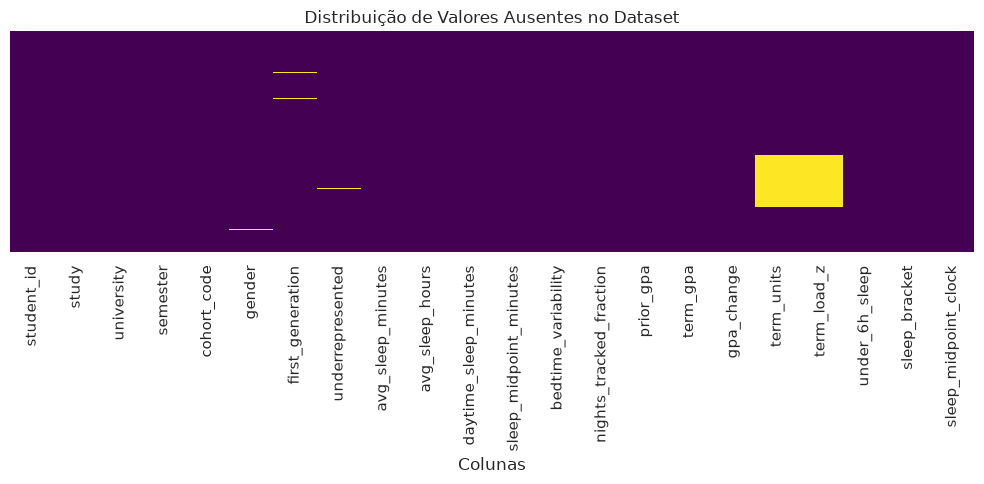

In [94]:
plt.figure(figsize=(10, 5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Distribuição de Valores Ausentes no Dataset')
plt.xlabel('Colunas')
plt.tight_layout()
plt.show()

/tmp/ipykernel_18149/3094989905.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos.index, y=nulos.values, palette='magma')


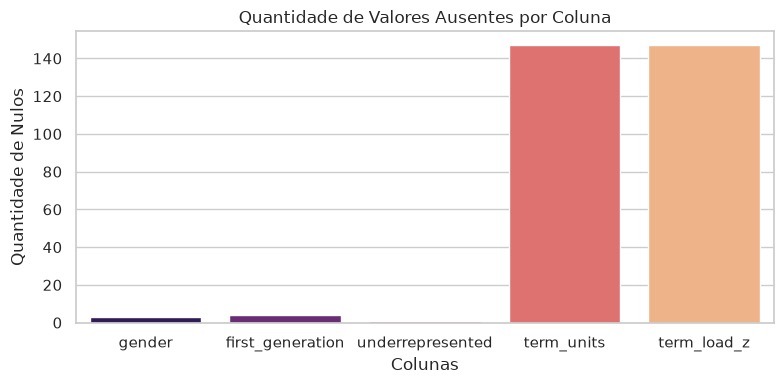

In [95]:
plt.figure(figsize=(8, 4))
sns.barplot(x=nulos.index, y=nulos.values, palette='magma')
plt.title('Quantidade de Valores Ausentes por Coluna')
plt.ylabel('Quantidade de Nulos')
plt.xlabel('Colunas')
plt.tight_layout()
plt.show()

In [96]:
dataLimpo = data.copy()

In [97]:
colInutil = [
    'avg_sleep_minutes',
    'term_units',
    'student_id',
    'sleep_midpoint_clock',
    'cohort_code',
    'study',
    'semester',
]
dataLimpo = dataLimpo.drop(columns=colInutil)

In [98]:
dataLimpo = dataLimpo.dropna(subset=['gender', 'first_generation', 'underrepresented'])

In [99]:
dataLimpo['term_load_z'] = dataLimpo['term_load_z'].fillna(dataLimpo['term_load_z'].median())
print(dataLimpo.isnull().sum())

university                 0
gender                     0
first_generation           0
underrepresented           0
avg_sleep_hours            0
daytime_sleep_minutes      0
sleep_midpoint_minutes     0
bedtime_variability        0
nights_tracked_fraction    0
prior_gpa                  0
term_gpa                   0
gpa_change                 0
term_load_z                0
under_6h_sleep             0
sleep_bracket              0
dtype: int64


In [100]:
colOut = [
    'avg_sleep_hours',
    'daytime_sleep_minutes',
    'sleep_midpoint_minutes',
    'bedtime_variability',
    'prior_gpa',
    'term_gpa',
    'gpa_change',
    'term_load_z'
]

for col in colOut:
    # Garantimos o cálculo dos percentis via NumPy
    Q1 = np.percentile(dataLimpo[col], 25)
    Q3 = np.percentile(dataLimpo[col], 75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # Filtra os outliers
    outliers = dataLimpo[(dataLimpo[col] < limite_inf) | (dataLimpo[col] > limite_sup)]
    
    print(f"{col}: {len(outliers)} outliers encontrados.")

avg_sleep_hours: 11 outliers encontrados.
daytime_sleep_minutes: 28 outliers encontrados.
sleep_midpoint_minutes: 15 outliers encontrados.
bedtime_variability: 93 outliers encontrados.
prior_gpa: 17 outliers encontrados.
term_gpa: 21 outliers encontrados.
gpa_change: 43 outliers encontrados.
term_load_z: 53 outliers encontrados.


In [101]:
transfLog =['bedtime_variability', 'daytime_sleep_minutes']
col_win_inf = ['prior_gpa', 'term_gpa']

for col in transfLog:
    dataLimpo[col] = np.log1p(dataLimpo[col])

dataLimpo['sleep_midpoint_minutes'] = winsorize(dataLimpo['sleep_midpoint_minutes'], limits=[0, 0.03])

for col in col_win_inf:
    dataLimpo[col] = winsorize(dataLimpo[col], limits=[0.05, 0])

dataLimpo['term_load_z'] = winsorize(dataLimpo['term_load_z'], limits=[0.03, 0.03])


In [102]:
colOut = [
    'avg_sleep_hours',
    'daytime_sleep_minutes',
    'sleep_midpoint_minutes',
    'bedtime_variability',
    'prior_gpa',
    'term_gpa',
    'gpa_change',
    'term_load_z'
]

for col in colOut:
    # Garantimos o cálculo dos percentis via NumPy
    Q1 = np.percentile(dataLimpo[col], 25)
    Q3 = np.percentile(dataLimpo[col], 75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # Filtra os outliers
    outliers = dataLimpo[(dataLimpo[col] < limite_inf) | (dataLimpo[col] > limite_sup)]
    
    print(f"{col}: {len(outliers)} outliers encontrados.")

avg_sleep_hours: 11 outliers encontrados.
daytime_sleep_minutes: 9 outliers encontrados.
sleep_midpoint_minutes: 0 outliers encontrados.
bedtime_variability: 81 outliers encontrados.
prior_gpa: 0 outliers encontrados.
term_gpa: 0 outliers encontrados.
gpa_change: 43 outliers encontrados.
term_load_z: 53 outliers encontrados.


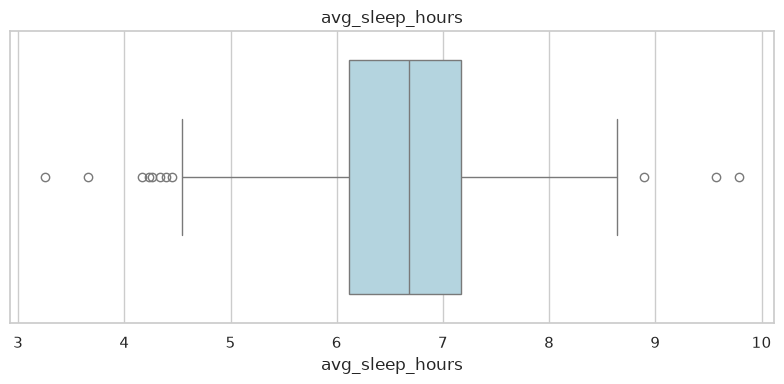

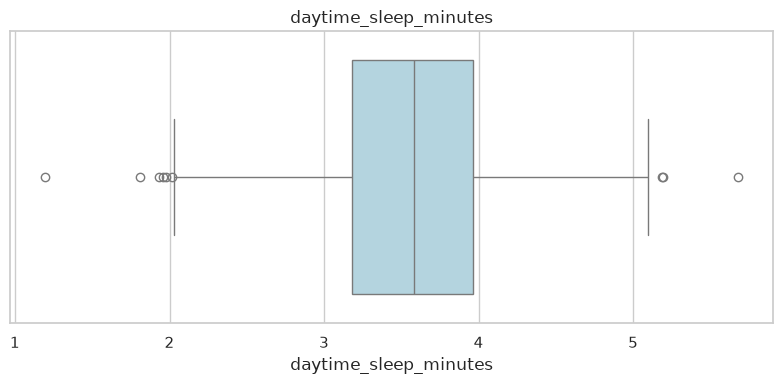

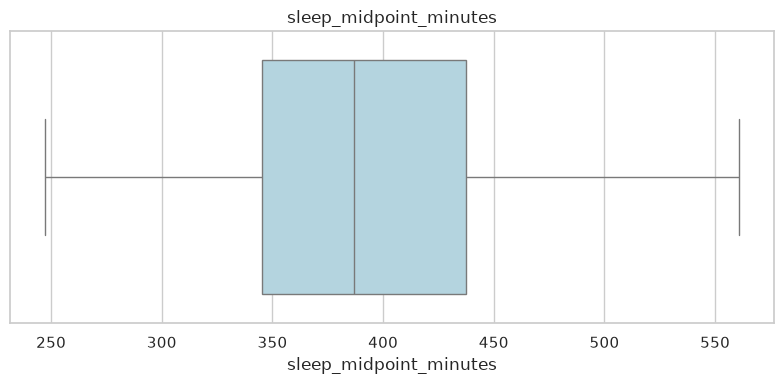

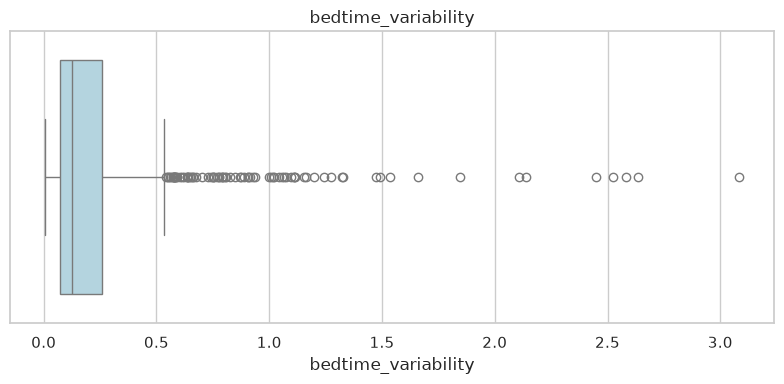

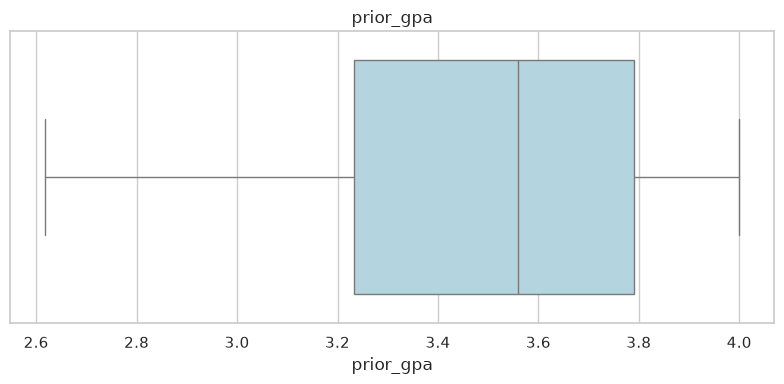

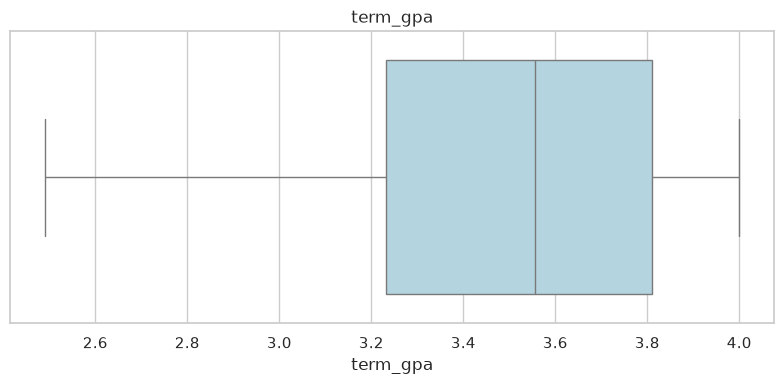

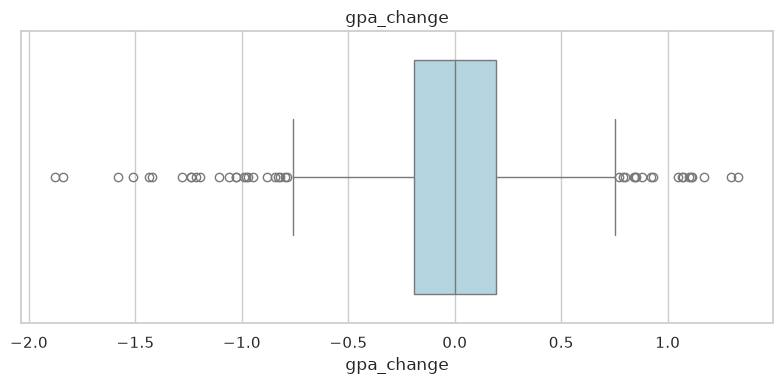

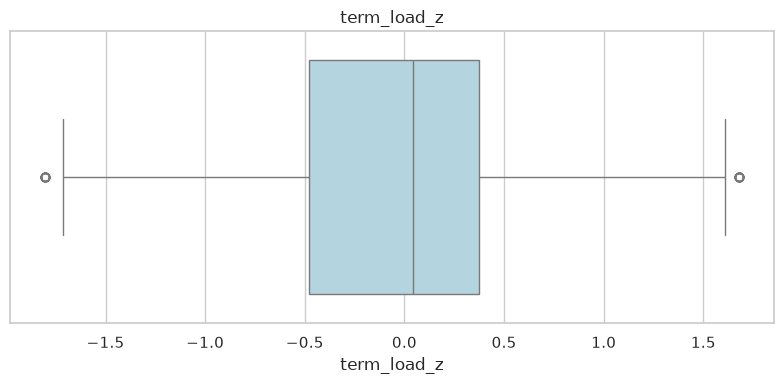

In [103]:
for col in colOut:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=dataLimpo[col], color='lightblue')
    plt.title(col)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [104]:
for col in colOut:
    media = dataLimpo[col].mean()
    desvio = data[col].std()
    
    z_scores = (dataLimpo[col] - media) / desvio
    
    outliers = dataLimpo[np.abs(z_scores) > 3]
    
    print(f"=== Coluna: {col} ===")
    print(f"Média: {media:.2f} | Desvio Padrão: {desvio:.2f}")
    print(f"Outliers detectados (|Z| > 3): {len(outliers)}")
    print("-" * 40)

=== Coluna: avg_sleep_hours ===
Média: 6.62 | Desvio Padrão: 0.85
Outliers detectados (|Z| > 3): 4
----------------------------------------
=== Coluna: daytime_sleep_minutes ===
Média: 3.57 | Desvio Padrão: 27.39
Outliers detectados (|Z| > 3): 0
----------------------------------------
=== Coluna: sleep_midpoint_minutes ===
Média: 396.98 | Desvio Padrão: 72.71
Outliers detectados (|Z| > 3): 0
----------------------------------------
=== Coluna: bedtime_variability ===
Média: 0.26 | Desvio Padrão: 1.39
Outliers detectados (|Z| > 3): 0
----------------------------------------
=== Coluna: prior_gpa ===
Média: 3.48 | Desvio Padrão: 0.44
Outliers detectados (|Z| > 3): 0
----------------------------------------
=== Coluna: term_gpa ===
Média: 3.47 | Desvio Padrão: 0.50
Outliers detectados (|Z| > 3): 0
----------------------------------------
=== Coluna: gpa_change ===
Média: -0.02 | Desvio Padrão: 0.40
Outliers detectados (|Z| > 3): 11
----------------------------------------
=== Coluna: ter

In [105]:
mediana_gpa = dataLimpo['term_gpa'].median()
dataLimpo['gpa_category'] = np.where(dataLimpo['term_gpa'] >= mediana_gpa, 'Alto', 'Baixo')

print(dataLimpo['gpa_category'].value_counts())

gpa_category
Alto     318
Baixo    308
Name: count, dtype: int64


/home/henderson/Documentos/AnaliseDeDadosSono/AnaliseDeDados/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [106]:
dataEncod = dataLimpo.copy()

In [107]:
brackets = []

for l in dataEncod['sleep_bracket']:
    if l not in brackets:
        brackets.append(l)

print("Brackets únicos encontrados:")
print(brackets)

Brackets únicos encontrados:
['6-6.5h', '6.5-7h', '<5.5h', '5.5-6h', '7-7.5h', '7.5h+']


In [108]:
bracketsEncod = {
    '<5.5h': 1,
    '5.5-6h': 2,
    '6-6.5h': 3,
    '6.5-7h': 4,
    '7-7.5h': 5,
    '7.5h+': 6,
}

dataEncod['sleep_bracket_encoded'] = dataEncod['sleep_bracket'].map(bracketsEncod)
dataEncod = dataEncod.drop(columns=['sleep_bracket'])


In [109]:
dataEncod['gpa_category_encoded'] = dataEncod['gpa_category'].map({'Alto': 1, 'Baixo': 0})
dataEncod = dataEncod.drop(columns=['gpa_category'])

In [110]:

dataEncod = pd.get_dummies(dataEncod, columns=['gender', 'university'], drop_first=True, dtype=int)

dataEncod.head()

,first_generation,underrepresented,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_load_z,under_6h_sleep,sleep_bracket_encoded,gpa_category_encoded,gender_Male,university_University of Notre Dame,university_University of Washington
0,0.0,0.0,6.17,2.541602,500.3,0.048790,0.931,4.00,3.76,-0.24,0.112,0,3,1,0,0,0
1,0.0,0.0,6.78,3.925926,359.5,0.046502,0.862,4.00,3.55,-0.45,0.112,0,4,0,0,0,0
2,0.0,1.0,4.23,5.190175,398.2,0.151776,0.586,3.00,3.59,0.59,-0.604,1,1,1,0,0,0
3,0.0,0.0,6.86,3.299534,532.1,0.579642,0.931,3.80,3.46,-0.34,-1.805,0,4,0,0,0,0
4,0.0,1.0,6.80,4.284965,354.0,0.143061,0.931,3.17,3.50,0.33,-1.805,0,4,0,0,0,0


In [111]:
scaler = StandardScaler()

colunas_continuas = [
    'avg_sleep_hours',
    'daytime_sleep_minutes',
    'sleep_midpoint_minutes',
    'bedtime_variability',
    'nights_tracked_fraction',
    'prior_gpa',
    'gpa_change',
    'term_load_z'
]

dataEncod[colunas_continuas] = scaler.fit_transform(dataEncod[colunas_continuas])

dataEncod.describe()

/home/henderson/Documentos/AnaliseDeDadosSono/AnaliseDeDados/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/home/henderson/Documentos/AnaliseDeDadosSono/AnaliseDeDados/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/home/henderson/Documentos/AnaliseDeDadosSono/AnaliseDeDados/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,first_generation,underrepresented,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_load_z,under_6h_sleep,sleep_bracket_encoded,gpa_category_encoded,gender_Male,university_University of Notre Dame,university_University of Washington
count,626.000000,626.000000,6.260000e+02,6.260000e+02,6.260000e+02,6.260000e+02,6.260000e+02,6.260000e+02,626.000000,6.260000e+02,6.260000e+02,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000
mean,0.166134,0.188498,-5.221241e-16,-2.724126e-16,5.675261e-18,4.540209e-17,-3.859178e-16,-6.810314e-16,3.474272,8.512892e-18,9.931708e-18,0.207668,3.758786,0.507987,0.418530,0.231629,0.439297
std,0.372499,0.391422,1.000800e+00,1.000800e+00,1.000800e+00,1.000800e+00,1.000800e+00,1.000800e+00,0.424842,1.000800e+00,1.000800e+00,0.405962,1.451386,0.500336,0.493713,0.422211,0.496698
min,0.000000,0.000000,-3.989062e+00,-3.944992e+00,-2.196071e+00,-6.878197e-01,-3.649348e+00,-2.246439e+00,2.490000,-4.600616e+00,-2.251545e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,-6.036795e-01,-6.384084e-01,-7.590404e-01,-5.064263e-01,-2.596457e-01,-6.516382e-01,3.233000,-4.292172e-01,-6.097322e-01,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,6.748378e-02,2.921435e-02,-1.462053e-01,-3.549026e-01,3.658019e-01,1.979285e-01,3.556000,3.921539e-02,3.584098e-02,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,6.469904e-01,6.548200e-01,5.955706e-01,-7.697589e-04,7.399536e-01,7.941156e-01,3.810000,5.181538e-01,4.472235e-01,0.000000,5.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,3.745577e+00,3.513592e+00,2.401841e+00,7.706269e+00,7.399536e-01,1.338460e+00,4.000000,3.331839e+00,2.066732e+00,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000


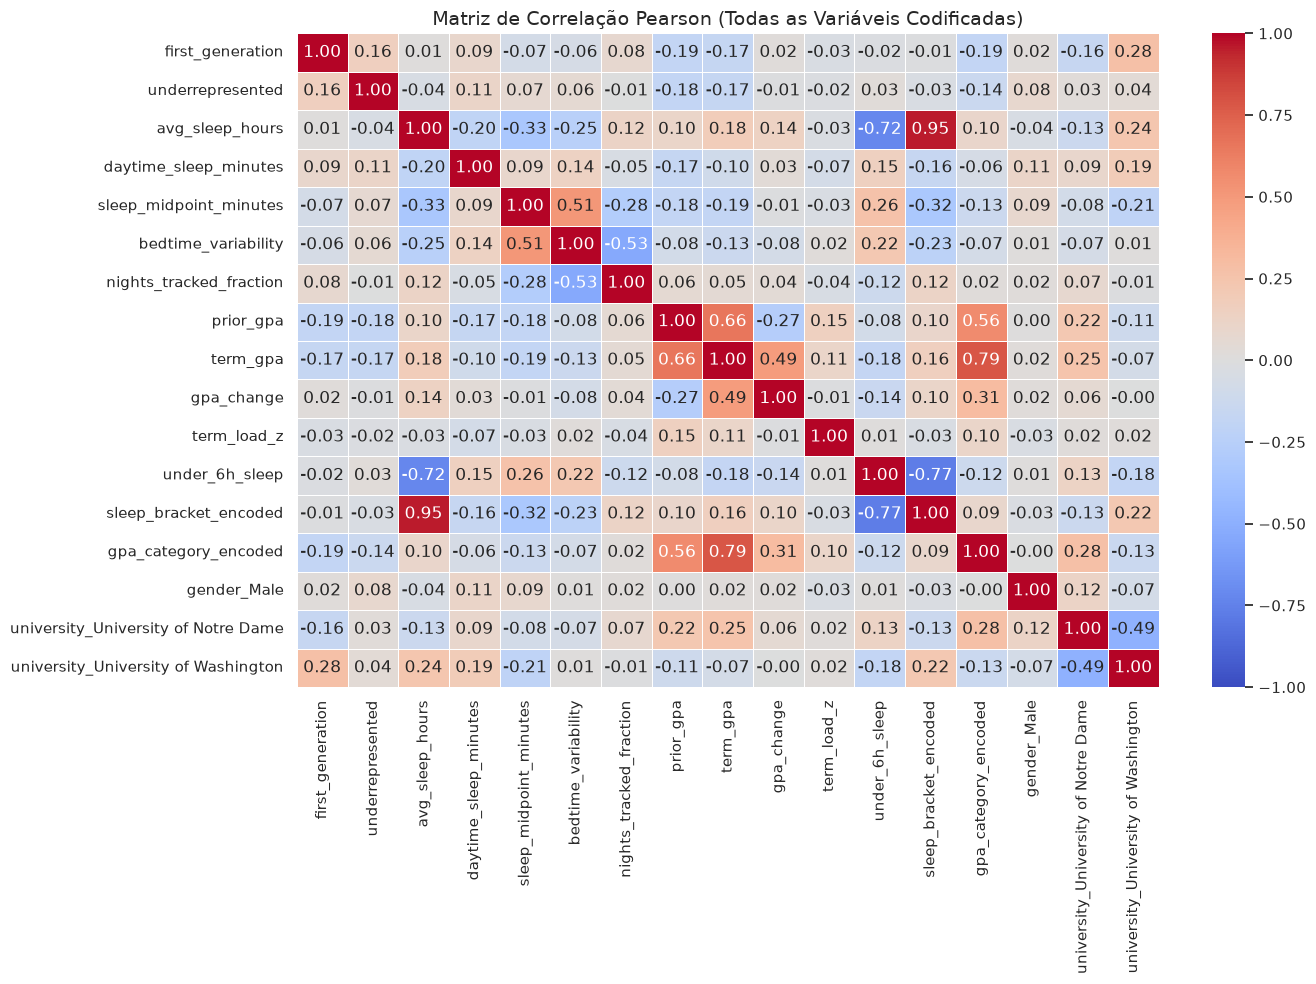

In [112]:
plt.figure(figsize=(14, 10))
matriz_corr = dataEncod.corr(method='pearson')

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Matriz de Correlação Pearson (Todas as Variáveis Codificadas)', fontsize=14)
plt.tight_layout()
plt.show()

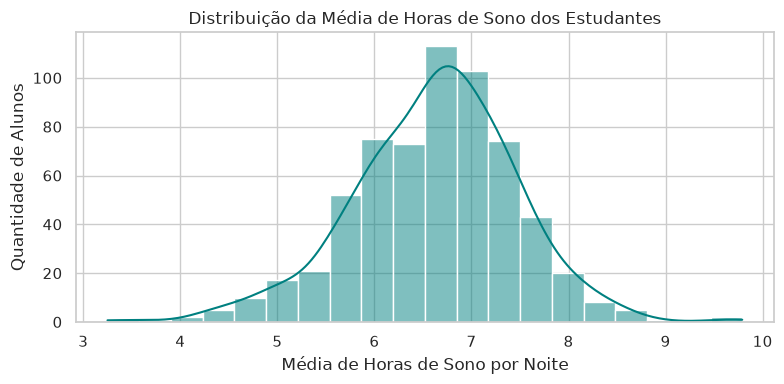

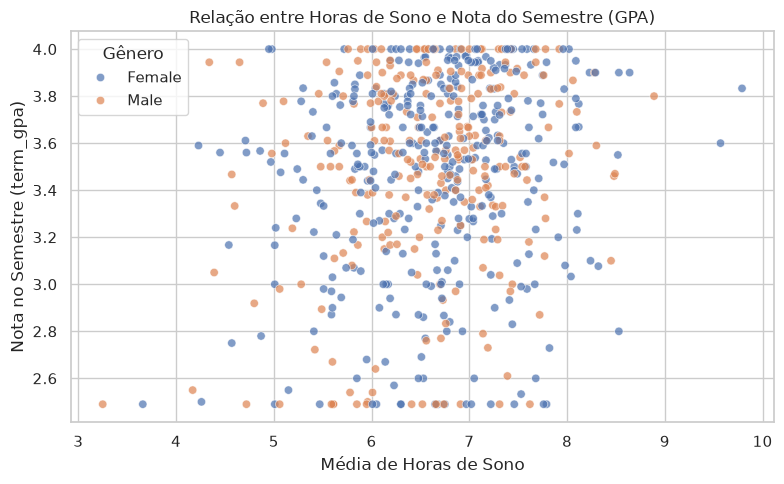

/tmp/ipykernel_18149/54076482.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


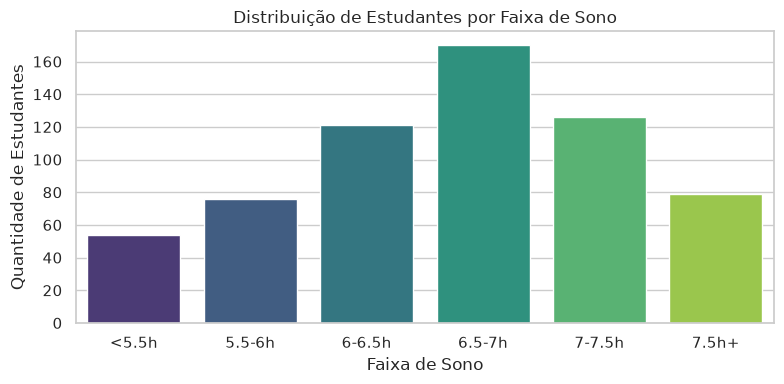

/tmp/ipykernel_18149/54076482.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataLimpo, x='university', y='term_gpa', palette='Set2')


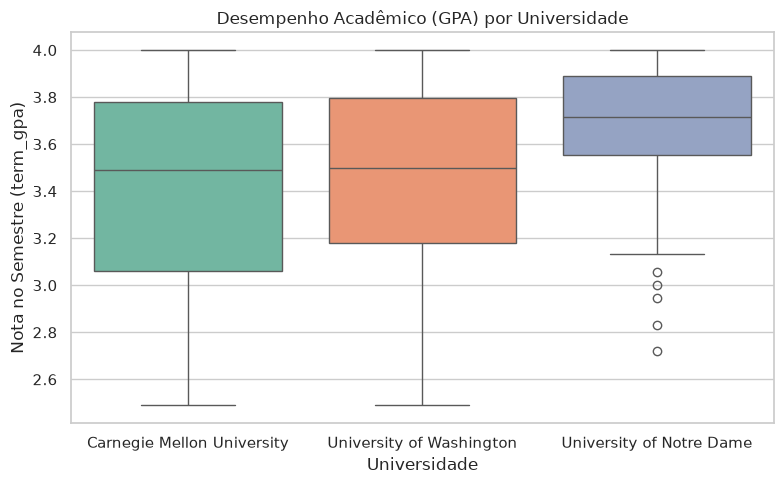

In [113]:


# Configuração de estilo dos gráficos
sns.set_theme(style='whitegrid')

# 1. Histograma: Distribuição de Horas de Sono
plt.figure(figsize=(8, 4))
sns.histplot(data=dataLimpo, x='avg_sleep_hours', kde=True, color='teal', bins=20)
plt.title('Distribuição da Média de Horas de Sono dos Estudantes', fontsize=12)
plt.xlabel('Média de Horas de Sono por Noite')
plt.ylabel('Quantidade de Alunos')
plt.tight_layout()
plt.show()

# 2. Scatterplot: Horas de Sono vs. Nota (GPA) por Gênero
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=dataLimpo,
    x='avg_sleep_hours',
    y='term_gpa',
    hue='gender',
    alpha=0.7
)
plt.title('Relação entre Horas de Sono e Nota do Semestre (GPA)', fontsize=12)
plt.xlabel('Média de Horas de Sono')
plt.ylabel('Nota no Semestre (term_gpa)')
plt.legend(title='Gênero')
plt.tight_layout()
plt.show()

# 3. Countplot: Distribuição de Estudantes por Faixa de Sono
plt.figure(figsize=(8, 4))
sns.countplot(
    data=dataLimpo,
    x='sleep_bracket',
    palette='viridis',
    order=['<5.5h', '5.5-6h', '6-6.5h', '6.5-7h', '7-7.5h', '7.5h+']
)
plt.title('Distribuição de Estudantes por Faixa de Sono', fontsize=12)
plt.xlabel('Faixa de Sono')
plt.ylabel('Quantidade de Estudantes')
plt.tight_layout()
plt.show()

# 4. Boxplot: Desempenho Acadêmico por Universidade
plt.figure(figsize=(8, 5))
sns.boxplot(data=dataLimpo, x='university', y='term_gpa', palette='Set2')
plt.title('Desempenho Acadêmico (GPA) por Universidade', fontsize=12)
plt.xlabel('Universidade')
plt.ylabel('Nota no Semestre (term_gpa)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_18149/2701131939.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gpa_category', y=col, data=dataLimpo, ax=axes[idx], palette='Set2')
/tmp/ipykernel_18149/2701131939.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gpa_category', y=col, data=dataLimpo, ax=axes[idx], palette='Set2')
/tmp/ipykernel_18149/2701131939.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gpa_category', y=col, data=dataLimpo, ax=axes[idx], palette='Set2')
/tmp/ipykernel_18149/2701131939.py:15: FutureWarning: 

Passing `palette` without 

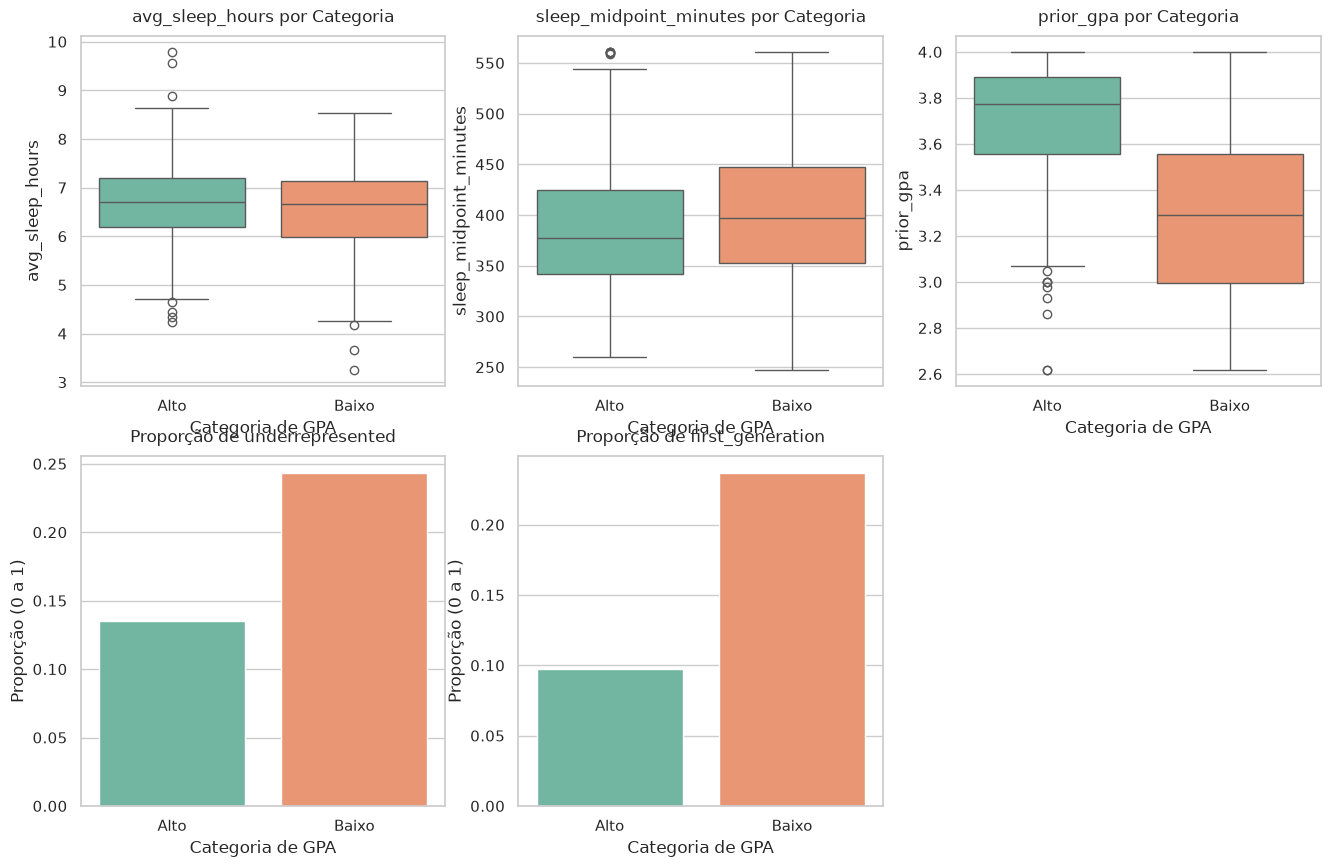

In [ ]:
features_continuas = ['avg_sleep_hours', 'sleep_midpoint_minutes', 'prior_gpa']
features_binarias = ['underrepresented', 'first_generation']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(features_continuas):
    sns.boxplot(x='gpa_category', y=col, data=dataLimpo, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} por Categoria', fontsize=12, pad=10)
    axes[idx].set_xlabel('Categoria de GPA')

# FOR 2: Variáveis binárias 0/1 (gerando Barplots de Proporção)
for idx, col in enumerate(features_binarias):
    ax_pos = idx + len(features_continuas)  # Ajusta o índice para continuar do subplot 3
    sns.barplot(x='gpa_category', y=col, data=dataLimpo, ax=axes[ax_pos], palette='Set2', errorbar=None)
    axes[ax_pos].set_title(f'Proporção de {col}', fontsize=12, pad=10)
    axes[ax_pos].set_xlabel('Categoria de GPA')
    axes[ax_pos].set_ylabel('Proporção (0 a 1)')

# Remove o 6º espaço do grid que sobrou
fig.delaxes(axes[5])

In [ ]:
grupo_alto = dataLimpo[dataLimpo['gpa_category'] == 'Alto']
grupo_baixo = dataLimpo[dataLimpo['gpa_category'] == 'Baixo']
features = ['avg_sleep_hours', 'sleep_midpoint_minutes', 'prior_gpa', 'underrepresented', 'first_generation']

print("=== TESTE T DE STUDENT (Alto vs Baixo Desempenho) ===")
for col in features:
    stat, p_val = stats.ttest_ind(grupo_alto[col], grupo_baixo[col])
    significativo = "Significativo (p < 0.05)" if p_val < 0.05 else "Não significativo"
    print(f"{col:25s} | p-valor: {p_val:.4f} -> {significativo}")

=== TESTE T DE STUDENT (Alto vs Baixo Desempenho) ===
avg_sleep_hours           | p-valor: 0.0162 -> Significativo (p < 0.05)
sleep_midpoint_minutes    | p-valor: 0.0010 -> Significativo (p < 0.05)
bedtime_variability       | p-valor: 0.0618 -> Não significativo
prior_gpa                 | p-valor: 0.0000 -> Significativo (p < 0.05)
